# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Hyacintha Shafa Athalia Hardianto
- **Email:** hyacintha.shafa@gmail.com
- **ID Dicoding:** CDCC006D6X1781

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?
- Kapan waktu puncak penyewaan sepeda berdasarkan jam dan hari dalam seminggu?
- Bagaimana perbedaan pola penggunaan sepeda antara pengguna casual dan pengguna registered?

## Import Semua Packages/Library yang Digunakan

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sn
import seaborn as sns
import zipfile
import requests
from io import BytesIO

In [106]:
url = 'https://drive.google.com/uc?id=1RaBmV6Q6FYWU4HWZs80Suqd7KQC34diQ'
content = requests.get(url)

zipfile = zipfile.ZipFile(BytesIO(content.content))

zipfile.extractall()

## Data Wrangling

In [107]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

### Gathering Data

In [108]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [109]:
hour_df.head(24)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


**Insight:**
- Dataframe `day_df` berisi data penyewaan sepeda secara harian yang mencakup variabel seperti tanggal (dteday), musim (season), tahun (yr), bulan (mnth), hari dalam seminggu (weekday), hari kerja (workingday), kondisi cuaca (weathersit), suhu (temp), suhu yang dirasakan (atemp), kelembaban (hum), kecepatan angin (windspeed), jumlah pengguna casual, pengguna registered, serta total penyewaan sepeda (cnt). Dataset ini digunakan untuk melihat pola penyewaan sepeda secara umum berdasarkan hari.
- Dataframe `hour_df` berisi data penyewaan sepeda secara lebih rinci berdasarkan jam. Dataset ini memiliki variabel yang hampir sama dengan `day_df`, namun ditambahkan variabel hr yang menunjukkan jam penyewaan sepeda. Dataset ini memungkinkan analisis yang lebih detail untuk mengetahui pola penyewaan sepeda berdasarkan waktu dalam satu hari.

### Assessing Data

In [110]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [111]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [112]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [113]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [114]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [115]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Berdasarkan proses assessing data, tidak ditemukan *missing value* dan data duplikat pada kedua dataset. Namun, terdapat beberapa variabel yang sebaiknya diubah tipe datanya, seperti variabel waktu dan kategori yang masih bertipe numerik. Variabel seperti season, year, month, weekday, holiday, workingday, dan weathersit sebaiknya diubah menjadi tipe kategori, sedangkan variabel dteday diubah menjadi tipe datetime untuk mempermudah analisis berbasis waktu.

### Cleaning Data

**Bike Sharing Dataset Day**

In [116]:
#Ubah Tipe Data Tanggal
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [117]:
#Ubah Tipe Data Kategori
categorical_columns = [
    "season",
    "yr",
    "mnth",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

for col in categorical_columns:
    day_df[col] = day_df[col].astype("category")

In [118]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    category      
 3   yr          731 non-null    category      
 4   mnth        731 non-null    category      
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    category      
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: category(7), datetime64

**Bike Sharing Dataset Hour**

In [119]:
#Ubah Tipe Data Tanggal
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [120]:
#Ubah Tipe Data Kategori
categorical_columns = [
    "season",
    "yr",
    "mnth",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

for col in categorical_columns:
    hour_df[col] = hour_df[col].astype("category")

In [121]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  category      
 3   yr          17379 non-null  category      
 4   mnth        17379 non-null  category      
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  category      
 7   weekday     17379 non-null  category      
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  category      
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Pada kedua dataset tidak ditemukan missing value dan duplikasi data, sehingga tidak memerlukan proses penghapusan atau imputasi data.
- Pada kedua dataset dilakukan proses pengubahan tipe data pada variabel dteday menjadi tipe data datetime. Selain itu, beberapa variabel seperti season, yr, mnth, holiday, weekday, workingday, dan weathersit diubah menjadi tipe kategori karena variabel tersebut merupakan data kategorikal.

## Exploratory Data Analysis (EDA)

### Explore `day_df`

In [122]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.0,731.0,731.0,731.0,731.0,731.0,731.0,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4.0,2.0,12.0,2.0,7.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,1.0,1.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188.0,366.0,62.0,710.0,105.0,500.0,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [123]:
print("Total Penyewaan Sepeda Keseluruhan")
total_rentals = day_df['cnt'].sum()
print(total_rentals)

Total Penyewaan Sepeda Keseluruhan
3292679


In [124]:
print("Total Pengguna Casual vs Registered")
day_df[["casual","registered"]].sum()

Total Pengguna Casual vs Registered


,0
casual,620017
registered,2672662


In [125]:
print("Penyewaan Berdasarkan Tahun")
day_df.groupby("yr")["cnt"].agg(['mean','sum','max','min'])

Penyewaan Berdasarkan Tahun


/tmp/ipykernel_14125/626024837.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby("yr")["cnt"].agg(['mean','sum','max','min'])


,mean,sum,max,min
yr,,,,
0,3405.761644,1243103,6043,431
1,5599.934426,2049576,8714,22


In [126]:
print("Pola Penyewaan Berdasarkan Musim")
day_df.groupby("season")[['cnt']].mean()

Pola Penyewaan Berdasarkan Musim


/tmp/ipykernel_14125/95257796.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby("season")[['cnt']].mean()


,cnt
season,
1,2604.132597
2,4992.331522
3,5644.303191
4,4728.162921


In [127]:
print("Pengaruh Kondisi Cuaca terhadap Penyewaan")
day_df.groupby("weathersit")["cnt"].agg(['mean','median','max'])

Pengaruh Kondisi Cuaca terhadap Penyewaan


/tmp/ipykernel_14125/2106472931.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby("weathersit")["cnt"].agg(['mean','median','max'])


,mean,median,max
weathersit,,,
1,4876.786177,4844.0,8714
2,4035.862348,4040.0,8362
3,1803.285714,1817.0,4639


In [128]:
print("Perbandingan Hari Kerja dan Hari Libur")
day_df.groupby("workingday")[['casual','registered','cnt']].mean()

Perbandingan Hari Kerja dan Hari Libur


/tmp/ipykernel_14125/1505600793.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby("workingday")[['casual','registered','cnt']].mean()


,casual,registered,cnt
workingday,,,
0,1371.134199,2959.034632,4330.168831
1,606.570000,3978.250000,4584.820000


**Insight:**
- **Ringkasan Statistik Data Penyewaan Sepeda Harian** :
Berdasarkan ringkasan statistik, didapatkan bahwa penyewaan sepeda harian terdiri dari 731 data dari tahun 2011 hingga 2012. Rata-Rata jumlah penyewaan sepeda per hari mencapai 4.504 sepeda, dengan jumlah minimum 22 sepeda dan maksimum 8.714 sepeda, menunjukkan variasi penyewaan yang cukup besar.
Pengguna registered mendominasi penyewaan dengan rata-rata 3.656 pengguna per hari, sedangkan pengguna casual hanya sekitar 848 pengguna per hari. Selain itu, sebagian besar penyewaan sepeda terjadi pada hari kerja, yang menunjukkan bahwa penyewaan sepeda lebih sering digunakan untuk aktivitas rutin atau bekerja.

- **Total Penyewaan Sepeda** :Total penyewaan sepeda selama periode tahun 2011 hingga 2012 mencapai 3.292.679 penyewaan.

- **Total Pengguna *Casual* dan *Registered***   : Total pengguna registered sebanyak 2.672.662 penyewa, jauh lebih tinggi dibandingkan pengguna casual yang berjumlah 620.017 penyewa.

- **Rata-Rata Penyewaan Sepeda Berdasarkan Musim** : Penyewaan sepeda tertinggi terjadi pada musim gugur  dengan rata-rata 5.644 penyewaan per hari, diikuti musim panas sebesar 4.992 penyewaan dan musim dingin  sebesar 4.728 penyewaan.
Sementara itu, penyewaan terendah terjadi pada musim semi dengan rata-rata 2.604 penyewaan per hari.

- **Rata-Rata Penyewaan Sepeda Berdasarkan Tahun** : Rata-rata penyewaan sepeda mengalami peningkatan dari tahun 2011 ke 2012. Pada tahun 2011, rata-rata penyewaan sebesar 3.405 sepeda per hari dengan total 1.243.103 penyewaan. Sedangkan pada tahun 2012, rata-rata meningkat menjadi 5.599 sepeda per hari dengan total 2.049.576 penyewaan.

- **Rata-Rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca** : Kondisi cuaca berpengaruh terhadap jumlah penyewaan sepeda. Pada kondisi cuaca cerah, rata-rata penyewaan mencapai 4.876 sepeda, lebih tinggi dibandingkan kondisi berawan dengan rata-rata 4.035 sepeda. Sementara itu, pada kondisi cuaca buruk , rata-rata penyewaan turun signifikan menjadi 1.803 sepeda.

- **Jumlah Penyewaan Sepeda pada *Weekday* dan *Weekend*** : Pada *weekend* rata-rata pengguna *casual* lebih tinggi yaitu 1.371 pengguna, dibandingkan *weekday* sebesar 606 pengguna. Sebaliknya, pengguna registered lebih banyak pada hari kerja dengan rata-rata 3.978 pengguna, dibandingkan hari libur sebesar 2.959 pengguna.

### Explore `hour_df`

In [129]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.0,17379.0,17379.0,17379.000000,17379.0,17379.0,17379.0,17379.0,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4.0,2.0,12.0,NaN,2.0,7.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,1.0,7.0,NaN,0.0,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496.0,8734.0,1488.0,NaN,16879.0,2512.0,11865.0,11413.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,11.546752,NaN,NaN,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [130]:
print("Rata-rata Penyewaan Berdasarkan Jam")
hour_df.groupby("hr")["cnt"].mean()

Rata-rata Penyewaan Berdasarkan Jam


,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


In [131]:
print("Rata-Rata Penyewaan Casual dan Registered per Jam")
hour_df.groupby("hr")[["casual","registered"]].mean()

Rata-Rata Penyewaan Casual dan Registered per Jam


,casual,registered
hr,,
0,10.158402,43.739669
1,6.504144,26.871547
2,4.772028,18.097902
3,2.715925,9.011478
4,1.253945,5.098996
5,1.411437,18.478382
6,4.161379,71.882759
7,11.055021,201.009629
8,21.679505,337.331499


In [132]:
print("Pola Jam Berdasarkan Hari Kerja")
hour_df.groupby(["workingday","hr"])["cnt"].mean()

Pola Jam Berdasarkan Hari Kerja


/tmp/ipykernel_14125/164447973.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby(["workingday","hr"])["cnt"].mean()


workingday  hr
0           0      90.800000
            1      69.508696
            2      53.171053
            3      25.775330
            4       8.264317
            5       8.689189
            6      18.742358
            7      43.406926
            8     105.653680
            9     171.623377
            10    255.909091
            11    315.316017
            12    366.259740
            13    372.731602
            14    364.645022
            15    358.813853
            16    352.727273
            17    323.549784
            18    281.056522
            19    231.673913
            20    174.739130
            21    142.060870
            22    116.060870
            23     85.930435
1           0      36.786290
            1      16.552632
            2       8.683778
            3       4.942553
            4       5.429787
            5      24.913131
            6     102.500000
            7     290.612903
            8     477.006048
            9     241.518145
            10    135.366935
            11    158.229839
            12    200.820926
            13    198.429719
            14    183.572289
            15    201.331325
            16    293.122244
            17    525.290581
            18    492.226908
            19    348.401606
            20    249.718876
            21    186.287149
            22    138.389558
            23     88.708835
Name: cnt, dtype: float64

**Insight:**
- **Ringkasan Statistik Data Penyewaan Sepeda Setiap Jam** : Didapatkan bahwa penyewaan sepeda setiap jam terdiri dari 17.379 data penyewaan sepeda per jam dari periode 2011 hingga 2012. Rata-rata jumlah penyewaan sepeda per jam sebesar 189 sepeda, dengan jumlah minimum 1 sepeda dan maksimum 977 sepeda, menunjukkan variasi penyewaan yang cukup besar setiap jam. Rata-rata pengguna registered sebesar 153 pengguna per jam, lebih tinggi dibandingkan pengguna casual sebesar 35 pengguna per jam.

- **Rata-Rata Penyewaan Sepeda Tiap Jam**: Penyewaan sepeda cenderung meningkat pada jam sibuk pagi dan sore hari. Puncak penyewaan terjadi pada jam 17.00 dengan rata-rata 461 penyewaan, diikuti jam 18.00 sebesar 425 penyewaan dan jam 08.00 sebesar 359 penyewaan. Jumlah penyewaan paling rendah terjadi pada jam dini hari, khususnya jam 03.00–04.00. Menunjukkan bahwa sepeda lebih banyak digunakan pada jam berangkat dan pulang kerja.

- **Rata-Rata Penyewaan Sepeda Pengguna *Casual* dan *Registered* Tiap Jam** : Pengguna registered mendominasi penyewaan pada jam sibuk pagi dan sore hari, khususnya pada jam 08.00 dan 17.00–18.00. Puncak tertinggi terjadi pada jam 17.00 dengan rata-rata 387 pengguna registered, yang menunjukkan penggunaan sepeda untuk aktivitas pulang kerja.Sementara itu, pengguna casual cenderung meningkat pada siang hingga sore hari, dengan jumlah tertinggi sekitar jam 14.00–17.00. Menunjukkan bahwa pengguna casual lebih sering menggunakan sepeda untuk aktivitas santai, sedangkan pengguna registered lebih banyak menggunakan sepeda untuk aktivitas rutin.

- **Rata-Rata Penyewaan Sepeda Berdasarkan Jam dan Hari Kerja** : Pada hari kerja penyewaan sepeda meningkat tajam pada jam 08.00 dan 17.00–18.00, dengan puncak tertinggi pada jam 17.00 sebesar 525 penyewaan. Pola ini menunjukkan bahwa sepeda banyak digunakan untuk aktivitas berangkat dan pulang kerja.Sebaliknya, pada hari libur penyewaan sepeda cenderung meningkat pada siang hingga sore hari, dengan puncak sekitar jam 13.00–15.00. Menunjukkan bahwa pada hari libur, sepeda lebih banyak digunakan untuk aktivitas santai.


## Visualization & Explanatory Analysis

In [133]:
main_data = hour_df.merge(
    day_df[["dteday"]],
    on="dteday",
    how="left"
)
main_data.to_csv("main_data.csv", index=False)
main_data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Pertanyaan 1:

/tmp/ipykernel_14125/305407732.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_df = main_data.groupby("weathersit")["cnt"].sum().reset_index()
/tmp/ipykernel_14125/305407732.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


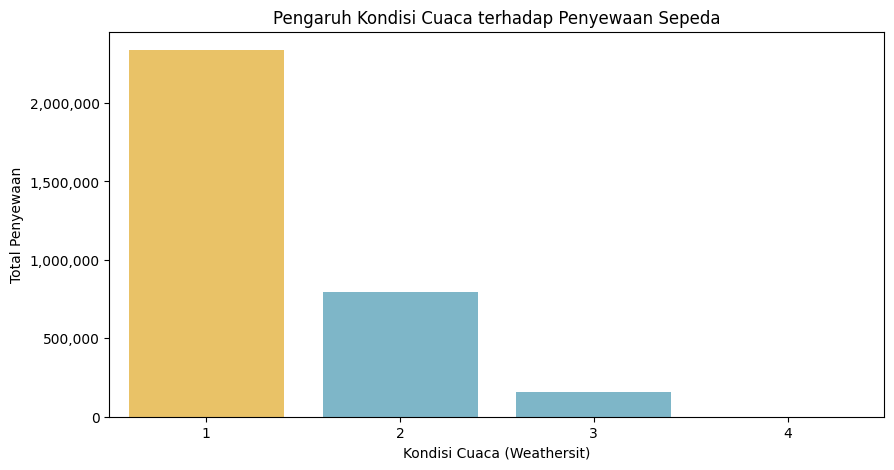

In [134]:
weather_df = main_data.groupby("weathersit")["cnt"].sum().reset_index()
max_value = weather_df["cnt"].max()
colors = ["#FECB52" if x == max_value else "#72BCD4" for x in weather_df["cnt"]]

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x="weathersit",
    y="cnt",
    data=weather_df,
    palette=colors
)

plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.title("Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda")
plt.xlabel("Kondisi Cuaca (Weathersit)")
plt.ylabel("Total Penyewaan")

plt.show()

### Pertanyaan 2:

/tmp/ipykernel_14125/146329928.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = main_data.pivot_table(


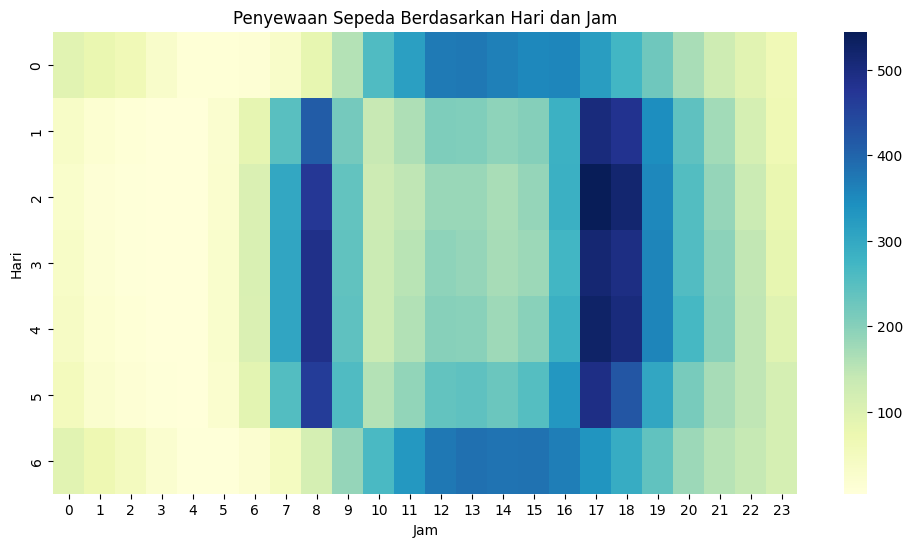

In [135]:
plt.figure(figsize=(12,6))

pivot_table = main_data.pivot_table(
    values='cnt',
    index='weekday',
    columns='hr',
    aggfunc='mean'
)

sns.heatmap(pivot_table, cmap="YlGnBu")

plt.title("Penyewaan Sepeda Berdasarkan Hari dan Jam")
plt.xlabel("Jam")
plt.ylabel("Hari")

plt.show()

### Pertanyaan 3:

/tmp/ipykernel_14125/670784555.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_df = main_data.groupby("weekday")[["casual","registered"]].mean().reset_index()


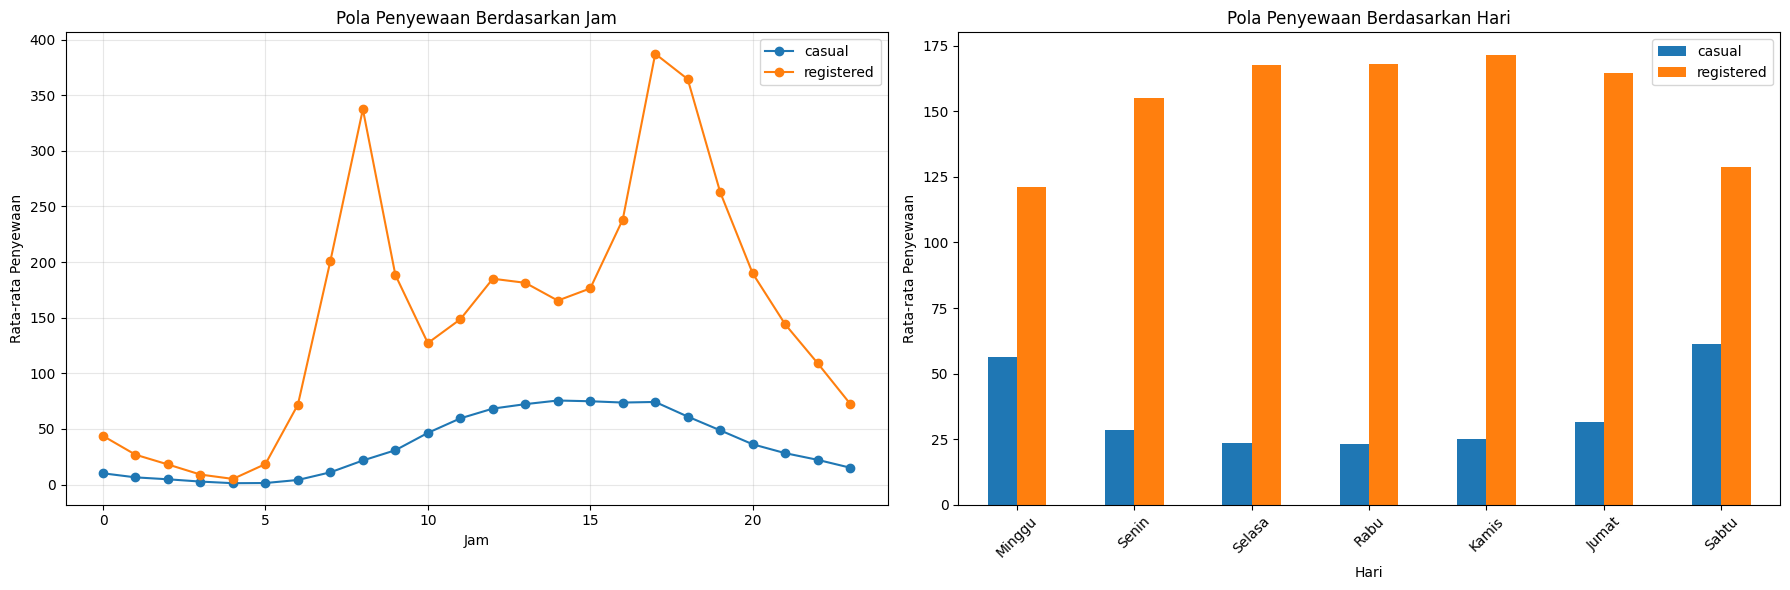

In [136]:
fig, ax = plt.subplots(1, 2, figsize=(18,6))

# Berdasarkan Jam
hourly_df = main_data.groupby("hr")[["casual","registered"]].mean()
hourly_df.plot(ax=ax[0], marker="o")

ax[0].set_title("Pola Penyewaan Berdasarkan Jam")
ax[0].set_xlabel("Jam")
ax[0].set_ylabel("Rata-rata Penyewaan")
ax[0].grid(alpha=0.3)


# Berdasarkan Hari
weekday_df = main_data.groupby("weekday")[["casual","registered"]].mean().reset_index()

day_map = {
    0: "Minggu",
    1: "Senin",
    2: "Selasa",
    3: "Rabu",
    4: "Kamis",
    5: "Jumat",
    6: "Sabtu"
}

weekday_df["weekday"] = weekday_df["weekday"].map(day_map)
weekday_df.set_index("weekday").plot(kind="bar", ax=ax[1])

ax[1].set_title("Pola Penyewaan Berdasarkan Hari")
ax[1].set_xlabel("Hari")
ax[1].set_ylabel("Rata-rata Penyewaan")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insight:**
- Penyewaan sepeda tertinggi pada kondisi cuaca baik dan penyewaan menurun saat kondisi cuaca memburuk.
- Penyewaan sepeda tertinggi terjadi pada pagi dan sore hari, hari kerja memiliki jumlah penyewaan lebih tinggi dibandingkan akhir pekan.
- Pengguna yang menyewa sepeda lebih banyak merupakan pengguna registered. Pengguna registered lebih banyak menggunakan pada hari kerja dan jam sibuk, sedangkan pada pengguna casual lebih banyak pada siang hari dan akhir pekan.

## Analisis Lanjutan (Opsional)

**Clustering (Manual Grouping)**

Tujuan dari clustering ini adalah untuk mengelompokkan tingkat penyewaan sepeda menjadi beberapa kategori (rendah, sedang, dan tinggi), sehingga mempermudah dalam mengidentifikasi pola penggunaan sepeda. Melalui pengelompokkan ini, diharapkan dapat diketahui karakteristik masing-masing cluster berdasarkan kondisi cuaca, waktu, dan faktor lainnya yang mempengaruhi jumlah penyewaan sepeda.

In [137]:
daily_main = main_data.groupby("dteday").agg({
    "cnt": "sum",
    "temp": "mean",
    "hum": "mean",
    "windspeed": "mean"
}).reset_index()

# Manual Grouping
cluster_df = daily_main[['cnt','temp','hum','windspeed']]

cluster_df['cluster'] = pd.cut(
    cluster_df['cnt'],
    bins=3,
    labels=['Rendah','Sedang','Tinggi']
)

cluster_df.head()

,cnt,temp,hum,windspeed,cluster
0,985,0.344167,0.805833,0.160446,Rendah
1,801,0.363478,0.696087,0.248539,Rendah
2,1349,0.196364,0.437273,0.248309,Rendah
3,1562,0.200000,0.590435,0.160296,Rendah
4,1600,0.226957,0.436957,0.186900,Rendah


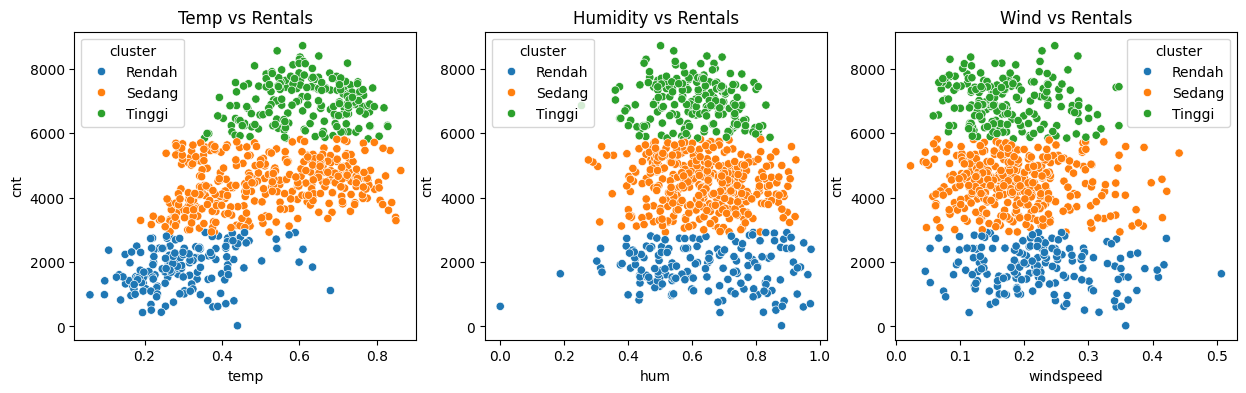

In [138]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.scatterplot(data=cluster_df, x='temp', y='cnt', hue='cluster')
plt.title("Temp vs Rentals")

plt.subplot(1,3,2)
sns.scatterplot(data=cluster_df, x='hum', y='cnt', hue='cluster')
plt.title("Humidity vs Rentals")

plt.subplot(1,3,3)
sns.scatterplot(data=cluster_df, x='windspeed', y='cnt', hue='cluster')
plt.title("Wind vs Rentals")

plt.show()

**Insight:**
- **Cluster Rendah**: Cluster ini menunjukkan jumlah penyewaan sepeda yang sedikit. Cluster ini umumnya terjadi pada suhu yang lebih rendah, kelembaban yang tinggi, dan kecepatan angin yang relatif besar.
- **Cluster Sedang**: Cluster imi menunjukkan jumlah penyewaan sepeda pada tingkat menengah. Cluster ini umumnya terjadi pada kondisi suhu yang cukup nyaman, dengan kelembaban dan kecepatan angin yang tidak terlalu ekstrem.
- **Cluster Tinggi**: Cluster ini menunjukkan jumlah penyewaan sepeda yang tinggi. Cluster ini terjadi pada suhu yang lebih nyaman, kelembaban yang sedang, dan kecepatan angin yang rendah.

## Conclusion

- **Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?** Jumlah penyewaan sepeda cenderung lebih tinggi pada kondisi cuaca baik dan menurun ketika kondisi cuaca memburuk. Hal ini menunjukkan bahwa kondisi cuaca memiliki pengaruh terhadap minat masyarakat dalam menyewa sepeda.
- **Kapan waktu puncak penyewaan sepeda berdasarkan jam dan hari dalam seminggu?**
Penyewaan sepeda mencapai puncaknya pada jam sibuk pagi dan sore hari, terutama pada hari kerja. Hal ini menunjukkan bahwa sepeda banyak digunakan sebagai sarana transportasi harian untuk aktivitas kerja atau sekolah.
- **Bagaimana perbedaan pola penggunaan sepeda antara pengguna casual dan registered?** Pengguna registered cenderung menggunakan sepeda pada jam sibuk di hari kerja, sedangkan pengguna casual lebih banyak menggunakan sepeda pada siang hari dan akhir pekan. Hal ini menunjukkan bahwa pengguna registered menggunakan sepeda untuk kebutuhan rutin, sementara pengguna casual lebih untuk rekreasi.


